# EDA On Google Playstore Dataset

---
1. Data Cleaning
2. EDA
3. Feature Engineering
---

# 1. Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
%matplotlib inline

df = pd.read_csv('googleplaystore.csv')
df_copy = df.copy()

---
#### Operations On Column: 'Reviews'

In [2]:
# df.shape
df_copy['Reviews'].str.isnumeric().sum()
df_copy[~df['Reviews'].str.isnumeric()]
df_copy = df_copy.drop(df_copy.index[10472])
df_copy[~df['Reviews'].str.isnumeric()]

df_copy['Reviews'].astype(int)


0           159
1           967
2         87510
3        215644
4           967
          ...  
10836        38
10837         4
10838         3
10839       114
10840    398307
Name: Reviews, Length: 10840, dtype: int64

---
#### Operations On Column: 'Size'

In [3]:
df_copy['Size'].isnull().sum()
df_copy['Size'] = df_copy['Size'].str.replace('M','000')
df_copy['Size'] = df_copy['Size'].str.replace('k','')
df_copy['Size'] = df_copy['Size'].replace('Varies with device',np.nan)
df_copy['Size'] = df_copy['Size'].astype(float)
df_copy['Size']



0        19000.0
1        14000.0
2            8.7
3        25000.0
4            2.8
          ...   
10836    53000.0
10837        3.6
10838        9.5
10839        NaN
10840    19000.0
Name: Size, Length: 10840, dtype: float64

---
#### Operations On Column: 'Installs' And 'Price'

In [4]:
chars_to_remove = ['+','$',',']
cols_to_clean = ['Installs', 'Price']

for item in chars_to_remove:
    for cols in cols_to_clean:
        df_copy[cols] = df_copy[cols].str.replace(item,'')

df_copy['Installs'] = df_copy['Installs'].astype(int)
df_copy['Price'] = df_copy['Price'].astype(float)

---
#### Operations On Column: 'Type'

In [5]:
df_copy['Type'] = df_copy['Type'].map({'Free':0, 'Paid':1, np.nan:0})
df_copy['Type'].unique()


array([0, 1])

---
#### Operations On Column: 'Last Updated'

In [6]:
df_copy['Last Updated'] = pd.to_datetime(df_copy['Last Updated'])
df_copy['Date'] = df_copy['Last Updated'].dt.day
df_copy['Month'] = df_copy['Last Updated'].dt.month
df_copy['Year'] = df_copy['Last Updated'].dt.year

In [7]:
df_copy.head(3)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Date,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,0,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,0,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,0,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018


---
# Saving File


In [8]:
df_copy.to_csv('04-googleplaystore-cleaned-data.csv', index=False)

---
# 2. EDA

---

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
%matplotlib inline

df = pd.read_csv('04-googleplaystore-cleaned-data.csv')
df_copy = df

---
#### Removing Duplicate

In [10]:
df_copy[df_copy.duplicated('App')].shape
df_copy = df_copy.drop_duplicates(subset=['App'], keep='first')

---
#### Exploring Data

In [11]:
numeric_features = [feature for feature in df_copy.columns if df_copy[feature].dtype != 'O']
categorical_features = [feature for feature in df_copy.columns if df_copy[feature].dtype == 'O']

print('We have {} numerical features: {}'.format(len(numeric_features), numeric_features))
print('We have {} Categorical features: {}'.format(len(categorical_features), categorical_features))

We have 9 numerical features: ['Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Date', 'Month', 'Year']
We have 7 Categorical features: ['App', 'Category', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


In [12]:
# df.drop('Unnamed: 0', axis=1, inplace=True)
# df_copy.drop('Unnamed: 0', axis=1, inplace=True)
df_copy.head(3)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Date,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,0,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,0,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,0,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018


---
#### Proportional of categories on categorical columns

In [13]:
for col in categorical_features:
    print(df_copy[col].value_counts(normalize=True)*100)
    print('----------------------------------------------------------')

App
iHoroscope - 2018 Daily Horoscope & Astrology         0.010353
Photo Editor & Candy Camera & Grid & ScrapBook        0.010353
Coloring book moana                                   0.010353
U Launcher Lite – FREE Live Cool Themes, Hide Apps    0.010353
Sketch - Draw & Paint                                 0.010353
                                                        ...   
Learn To Draw Kawaii Characters                       0.010353
3D Color Pixel by Number - Sandbox Art Coloring       0.010353
Mandala Coloring Book                                 0.010353
Tattoo Name On My Photo Editor                        0.010353
Name Art Photo Editor - Focus n Filters               0.010353
Name: proportion, Length: 9659, dtype: float64
----------------------------------------------------------
Category
FAMILY                 18.966767
GAME                    9.928564
TOOLS                   8.561963
BUSINESS                4.348276
MEDICAL                 4.089450
PERSONALIZATION        

---
#### Visualization for Proportion of Numerical features

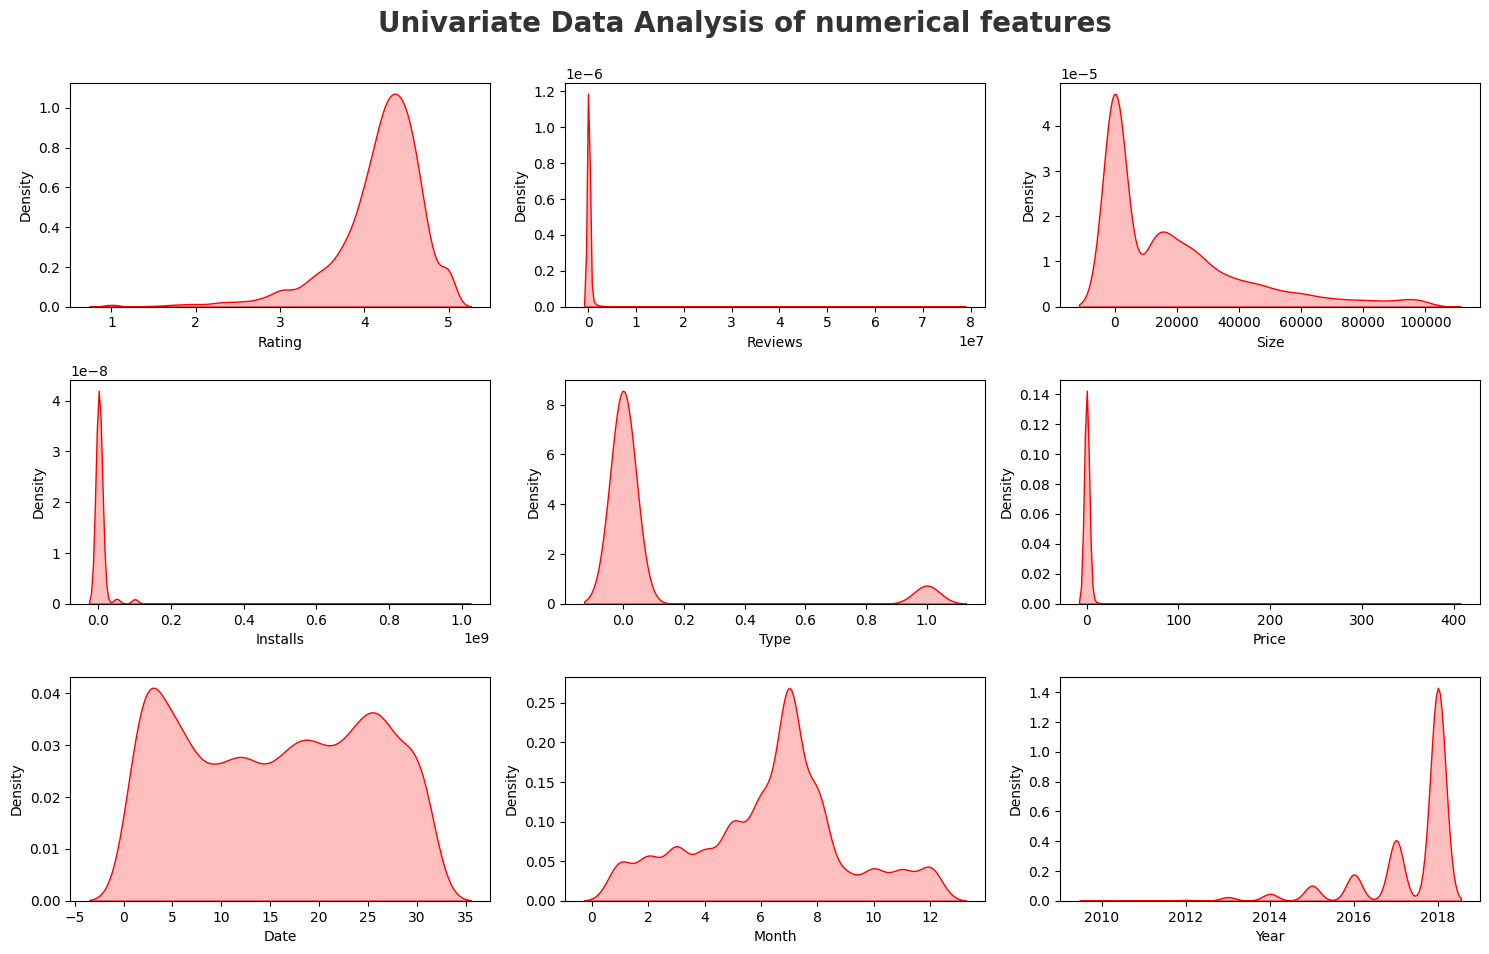

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,15))
plt.suptitle('Univariate Data Analysis of numerical features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(5, 3, i+1)
    sns.kdeplot(x=df_copy[numeric_features[i]], shade=True, color='r')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

---
#### Visualization for Proportion of Categorical features

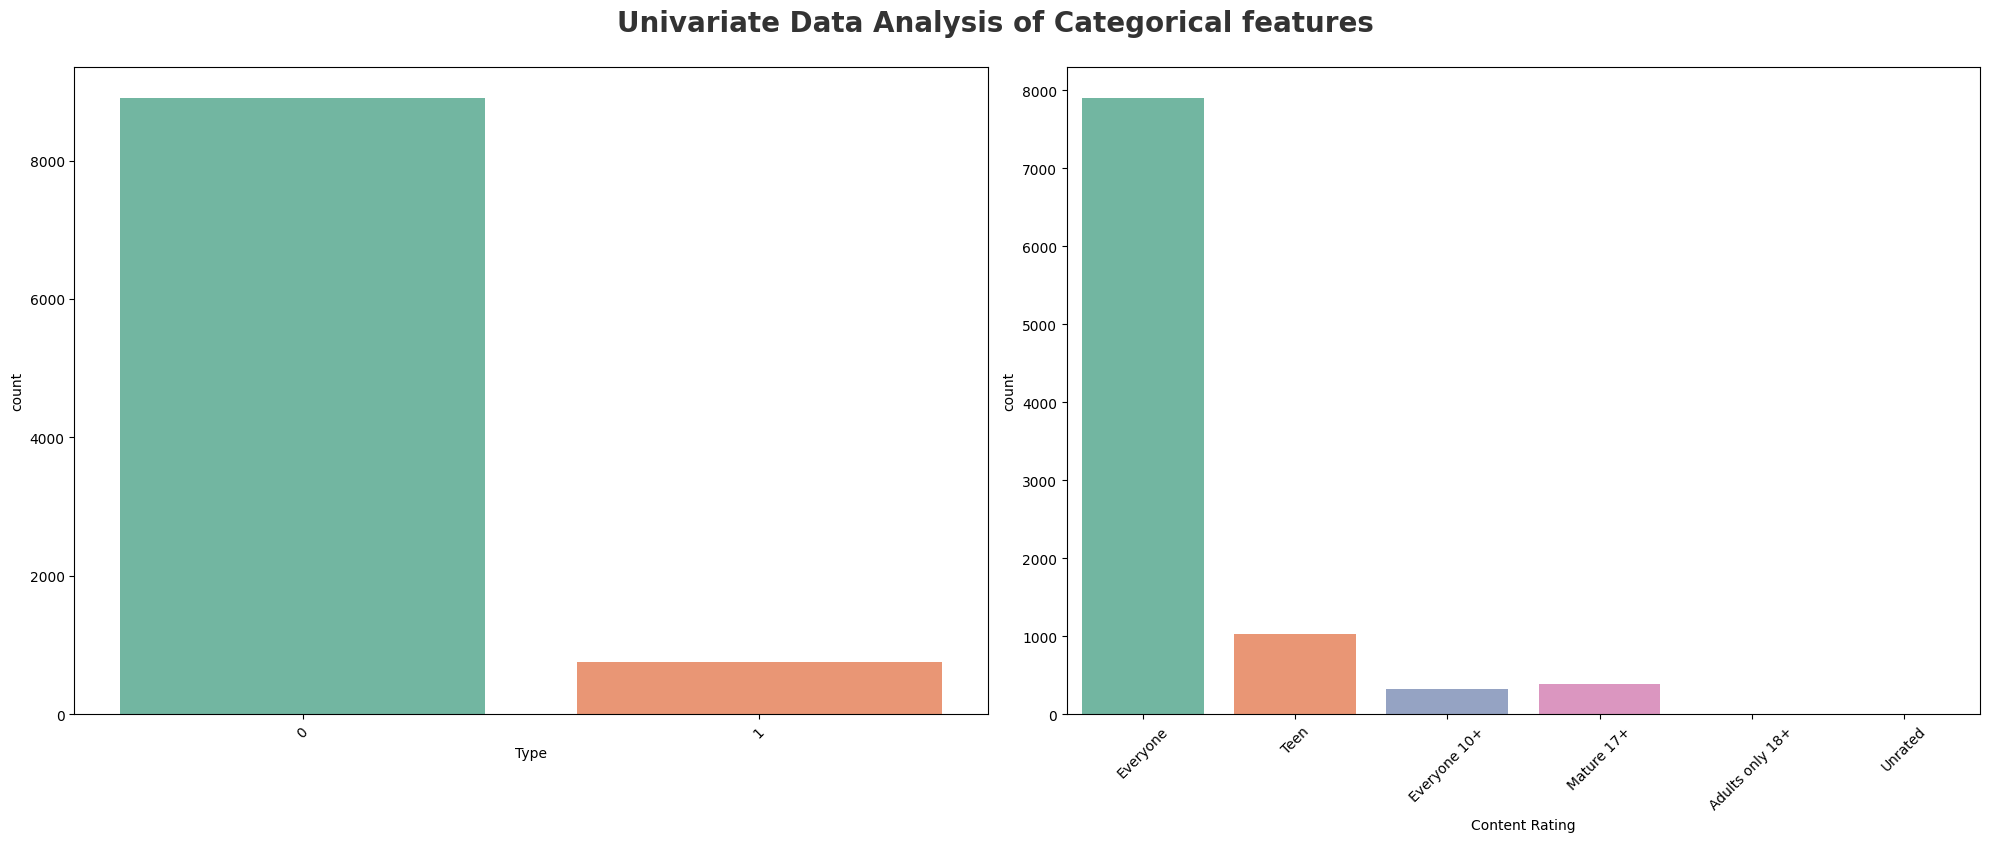

In [18]:
plt.figure(figsize=(20,15))
plt.suptitle('Univariate Data Analysis of Categorical features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)
category = ['Type', 'Content Rating']

for i in range(0, len(category)):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=df_copy[category[i]],palette="Set2")
    plt.xlabel(category[i])
    plt.xticks(rotation=45)
    plt.tight_layout()